# CLIP으로 이미지와 텍스트 매칭

CLIP(Contrastive Language-Image Pre-training)은 이미지와 문장을 각각 벡터로 바꾸고 같은 의미의 벡터가 가까워지도록 학습한 모델이다. 새로운 분류기를 학습하지 않아도 이미지와 여러 후보 문장의 유사도를 비교할 수 있어 zero-shot 이미지 분류와 이미지 검색에 사용한다.

이미지 encoder와 텍스트 encoder는 서로 다른 입력을 같은 embedding 공간으로 보낸다. 이 노트북에서는 BLIP 공식 예제 이미지와 네 문장을 전처리하고, CLIP의 logits와 정규화 embedding의 cosine similarity가 같은 최상위 문장을 선택하는지 확인한다.

## 전체 처리 흐름

이미지와 후보 문장을 CLIP 입력으로 바꾼 뒤, logits와 cosine similarity를 각각 계산한다. 마지막에는 두 방식이 같은 문장을 가장 유사하다고 선택하는지 비교한다.

```mermaid
flowchart TD
    A["BLIP 예제 이미지<br/>blip_demo.jpg"] --> B["RGB 이미지로 읽기"]
    C["후보 문장 4개"] --> D["CLIPProcessor 전처리"]
    B --> D
    D --> E["pixel_values<br/>input_ids·attention_mask"]
    E --> F["CLIPModel 추론"]
    F --> G["logits_per_image"]
    G --> H["softmax 확률"]
    H --> I["후보 문장 순위"]
    E --> J["이미지·문장 embedding 생성"]
    J --> K["L2 정규화"]
    K --> L["cosine similarity"]
    L --> M["후보 문장 순위"]
    I --> N["두 방식의 top-1 비교"]
    M --> N
```

`logits` 경로는 모델의 점수를 확률로 바꾸고, `embedding` 경로는 두 벡터의 방향이 얼마나 비슷한지 직접 계산한다.

## 실행 환경과 패키지


In [4]:
%pip install transformers==4.56.2 pillow==12.2.0 requests==2.34.2 matplotlib==3.11.1

   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------- ------------------------- 2.6/7.1 MB 15.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.0/7.1 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 14.6 MB/s  0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 12.3.0
    Uninstalling pillow-12.3.0:
      Successfully uninstalled pillow-12.3.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


## 예제 이미지 내려받기

예제 이미지는 노트북 실행 위치의 `data/multimodal_rag/images`에 저장한다. 파일이 없을 때만 다운로드하며, 저장된 이미지는 다음 셀의 시각화와 CLIP 입력으로 사용한다.

In [5]:
from pathlib import Path

import requests

IMAGE_URL = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
IMAGE_PATH = Path("data/multimodal_rag/images/blip_demo.jpg")
IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)

if not IMAGE_PATH.exists():
    response = requests.get(IMAGE_URL, timeout=30)
    response.raise_for_status()
    IMAGE_PATH.write_bytes(response.content)

print(f"IMAGE_PATH={IMAGE_PATH}")

IMAGE_PATH=data\multimodal_rag\images\blip_demo.jpg


## RGB 이미지 확인

`PIL.Image.open`은 저장된 파일을 이미지 객체로 읽고, `convert("RGB")`는 채널 구성을 빨강·초록·파랑의 3채널로 통일한다. 화면에서는 이미지 내용과 `(너비, 높이)`가 정상인지 확인한다. 이 이미지 한 장이 뒤에서 네 후보 문장과 비교되는 입력이다.

image_size=(2048, 1365), mode=RGB


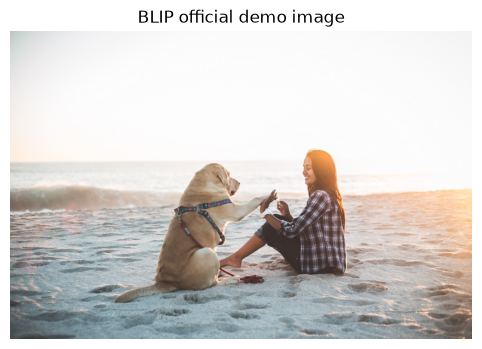

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(IMAGE_PATH).convert("RGB")
print(f"image_size={image.size}, mode={image.mode}")

plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis("off")
plt.title("BLIP official demo image")
plt.show()

## CLIP 모델과 processor 준비

`CLIPProcessor`는 이미지를 Tensor로 바꾸고 문장을 token ID로 변환한다. `CLIPModel`은 이미지 encoder와 텍스트 encoder를 함께 포함한다. `from_pretrained`는 모델 ID에 해당하는 전처리 규칙과 가중치를 내려받는다.

In [7]:
import os

os.environ["USE_TF"] = "0"

import torch
from transformers import CLIPModel, CLIPProcessor

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_ID,
    use_fast=False,
)
model = CLIPModel.from_pretrained(CLIP_MODEL_ID)
model.to(DEVICE)
model.eval()

print(f"model_id={CLIP_MODEL_ID}")
print(f"device={DEVICE}")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

C:\Users\playdata2\miniforge3\envs\llm_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\playdata2\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model_id=openai/clip-vit-base-patch32
device=cpu


## 이미지와 후보 문장 전처리

후보 문장 네 개는 이미지에 대한 가능한 설명이다. processor의 `text`에는 문장 목록, `images`에는 이미지 한 장을 전달한다. `return_tensors="pt"`는 PyTorch Tensor를 반환하고, `padding=True`는 문장 길이를 현재 배치의 가장 긴 문장에 맞춘다.

`pixel_values`의 shape는 `(B, C, H, W)`이며 각각 이미지 수, 채널, 높이, 너비이다. `input_ids`와 `attention_mask`의 shape는 `(N, T)`이며 각각 후보 문장 수와 token 길이이다.

In [8]:
candidate_texts = [
    "A woman and a dog are sitting on a beach.",
    "A cyclist is riding through a city street.",
    "A bowl of fruit is on a kitchen table.",
    "A train is moving through snowy mountains.",
]

inputs = processor(
    text=candidate_texts,
    images=image,
    return_tensors="pt",
    padding=True,
)

inputs = {name: tensor.to(DEVICE) for name, tensor in inputs.items()}
for name, tensor in inputs.items():
    print(f"{name}: shape={tuple(tensor.shape)}, dtype={tensor.dtype}")

input_ids: shape=(4, 13), dtype=torch.int64
attention_mask: shape=(4, 13), dtype=torch.int64
pixel_values: shape=(1, 3, 224, 224), dtype=torch.float32


## logits와 후보별 probability

`logits_per_image`는 이미지 한 장과 각 문장의 유사도에 학습된 크기 조절값을 적용한 점수이다. `softmax(dim=-1)`는 네 점수를 합이 1인 상대 probability로 바꾼다. 이 값은 후보 목록 안에서의 상대 비교이며, 문장 자체가 절대적으로 옳을 확률을 뜻하지 않는다.

In [9]:
with torch.inference_mode():
    outputs = model(**inputs)
    image_logits = outputs.logits_per_image[0]
    probabilities = image_logits.softmax(dim=-1)

ranking = torch.argsort(probabilities, descending=True).tolist()
for rank, index in enumerate(ranking, start=1):
    print(
        f"{rank}. probability={probabilities[index].item():.4f} "
        f"| logit={image_logits[index].item():.4f} | {candidate_texts[index]}"
    )
print(f"probability_sum={probabilities.sum().item():.4f}")

1. probability=1.0000 | logit=31.2709 | A woman and a dog are sitting on a beach.
2. probability=0.0000 | logit=16.6337 | A bowl of fruit is on a kitchen table.
3. probability=0.0000 | logit=14.9874 | A train is moving through snowy mountains.
4. probability=0.0000 | logit=11.4677 | A cyclist is riding through a city street.
probability_sum=1.0000


## 정규화 embedding의 cosine similarity

이미지와 문장 embedding은 방향과 크기를 가진 벡터이다. `normalize(..., dim=-1)`로 각 벡터의 길이를 1로 만들면 두 벡터의 내적이 cosine similarity가 된다. 값이 클수록 두 벡터의 방향, 즉 의미가 더 비슷하다고 해석한다.

CLIP의 logits는 cosine similarity에 학습된 scale을 적용하므로 두 방식의 점수 크기는 다르지만 일반적으로 후보 순서는 같다. 다음 셀은 두 방식의 최상위 index가 같은지 비교한다.

In [10]:
import torch.nn.functional as F

with torch.inference_mode():

    # (1,3,224,224) 픽셀 입력을 CLIP의 Image Encoder를 통과 시켜
    # (1, D) 벡터를 만든다
    # - D = Embedding 차원 수
    image_embedding = model.get_image_features(
        pixel_values=inputs["pixel_values"]
    )

    # 후보 문장(4개)를 CLIP의 TEXT Encoder를 통과시켜
    # (4, D) 벡터로 만든다.
    text_embeddings = model.get_text_features(
        input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]
    )

# 정규화 (p=2 == L2 Norm == Euclidean Norm)
image_embedding = F.normalize(image_embedding, dim=-1, p=2)
text_embeddings = F.normalize(text_embeddings, dim=-1, p=2)

# cos 유사도 점수 측정
cosine_scores = (image_embedding @ text_embeddings.T)[0]

cosine_ranking = torch.argsort(cosine_scores, descending=True).tolist()

for rank, index in enumerate(cosine_ranking, start=1):
    print(f"{rank}. cosine={cosine_scores[index].item():.4f} | {candidate_texts[index]}")
print(f"same_top1={ranking[0] == cosine_ranking[0]}")
print(f"image_embedding_shape={tuple(image_embedding.shape)}")
print(f"text_embeddings_shape={tuple(text_embeddings.shape)}")

1. cosine=0.3127 | A woman and a dog are sitting on a beach.
2. cosine=0.1663 | A bowl of fruit is on a kitchen table.
3. cosine=0.1499 | A train is moving through snowy mountains.
4. cosine=0.1147 | A cyclist is riding through a city street.
same_top1=True
image_embedding_shape=(1, 512)
text_embeddings_shape=(4, 512)
